# Phân tích Dữ liệu Tutorial Round (Round 0)
Notebook này nhằm mục đích:
1. Đọc và trực quan hoá dữ liệu giá của sản phẩm (ví dụ: `EMERALDS`, `TOMATOES`) trong dữ liệu hướng dẫn.
2. Hiển thị những vị trí đặt lệnh mua bán trên thị trường.
3. Phát hiện những lệnh mua bán có khối lượng bất thường.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style mặc định
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Load Dữ liệu
Load dữ liệu giá (`prices_round_0_day_-1.csv`) và dữ liệu giao dịch (`trades_round_0_day_-1.csv`).

In [15]:
prices_file = "i:/Prosperity/data/TUTORIAL_ROUND/prices_round_0_day_-1.csv"
trades_file = "i:/Prosperity/data/TUTORIAL_ROUND/trades_round_0_day_-1.csv"

df_prices = pd.read_csv(prices_file, sep=';')
df_trades = pd.read_csv(trades_file, sep=';')

# Hiển thị vài dòng đầu
display(df_prices.head())
display(df_trades.head())

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,5,4998,15,NaN,NaN,5013,5,5014,15,NaN,NaN,5006.0,0.0
1,-1,0,EMERALDS,9992,14,9990,29,NaN,NaN,10008,14,10010,29,NaN,NaN,10000.0,0.0
2,-1,100,EMERALDS,9992,11,9990,22,NaN,NaN,10008,11,10010,22,NaN,NaN,10000.0,0.0
3,-1,100,TOMATOES,5000,8,4998,21,NaN,NaN,5013,8,5014,21,NaN,NaN,5006.5,0.0
4,-1,200,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0


,timestamp,buyer,seller,symbol,currency,price,quantity
0,3200,NaN,NaN,EMERALDS,XIRECS,9992.0,8
1,3400,NaN,NaN,TOMATOES,XIRECS,5009.0,2
2,5000,NaN,NaN,EMERALDS,XIRECS,9992.0,7
3,7000,NaN,NaN,TOMATOES,XIRECS,5010.0,4
4,9600,NaN,NaN,TOMATOES,XIRECS,4999.0,5


## 2. Tiền xử lý
Tách riêng rẽ dữ liệu theo sản phẩm.

In [16]:
products = df_prices['product'].unique()
print(f"Các sản phẩm trong round 0: {products}")

# Lấy dataframe riêng cho EMERALDS và TOMATOES
df_emeralds = df_prices[df_prices['product'] == 'EMERALDS'].copy()
df_tomatoes = df_prices[df_prices['product'] == 'TOMATOES'].copy()

Các sản phẩm trong round 0: ['TOMATOES' 'EMERALDS']


## 3. Trực quan hóa Giá
Vẽ biểu đồ giá Mid Price của sản phẩm qua thời gian.

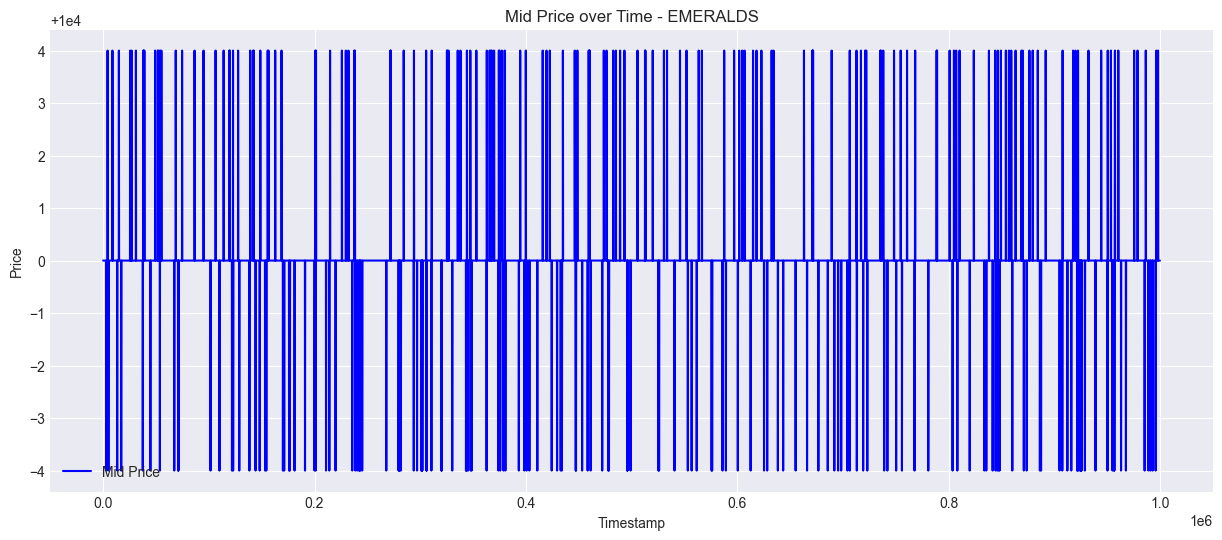

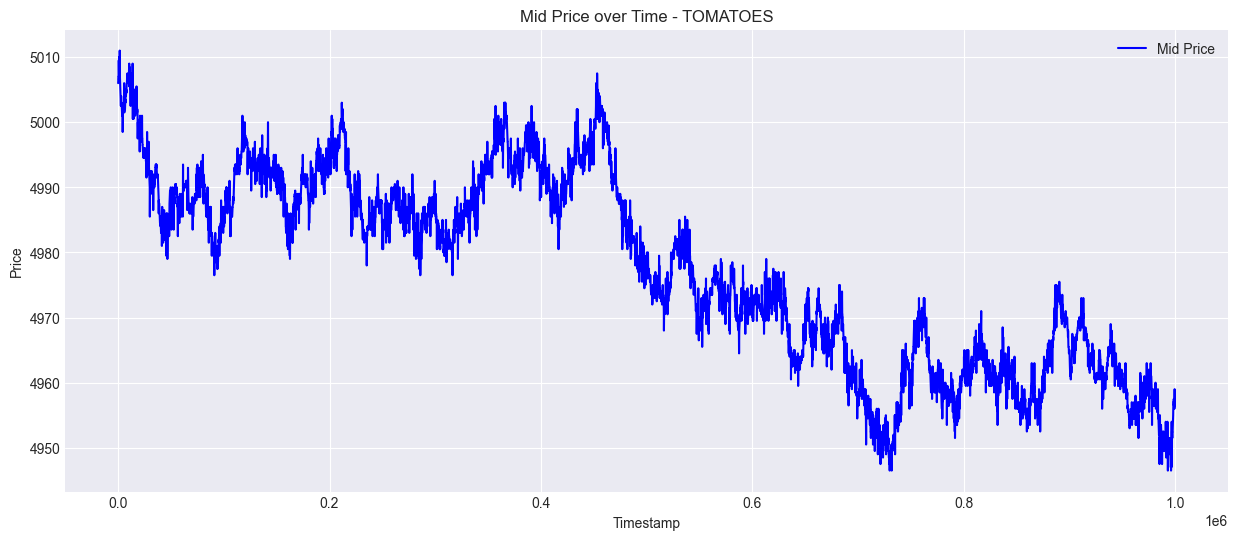

In [17]:
def plot_mid_price(df, product_name):
    plt.figure(figsize=(15, 6))
    plt.plot(df['timestamp'], df['mid_price'], label='Mid Price', color='blue')
    plt.title(f'Mid Price over Time - {product_name}')
    plt.xlabel('Timestamp')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

# Vẽ cho cả 2 sản phẩm
plot_mid_price(df_emeralds, 'EMERALDS')
plot_mid_price(df_tomatoes, 'TOMATOES')

## 4. Phân tích Lệnh Giao Dịch
Vẽ Order Book Spreads. Vị trí Bid và Ask của thị trường. Nhìn trên toàn bộ dữ liệu sẽ rất đặc, nên ta chỉ **zoom vào 200 tick đầu tiên** và tô màu vùng Spread (khoảng chênh lệch Bid - Ask). Mức độ hẹp/rộng của spread cho ta biết thanh khoản đang tốt hay kém.

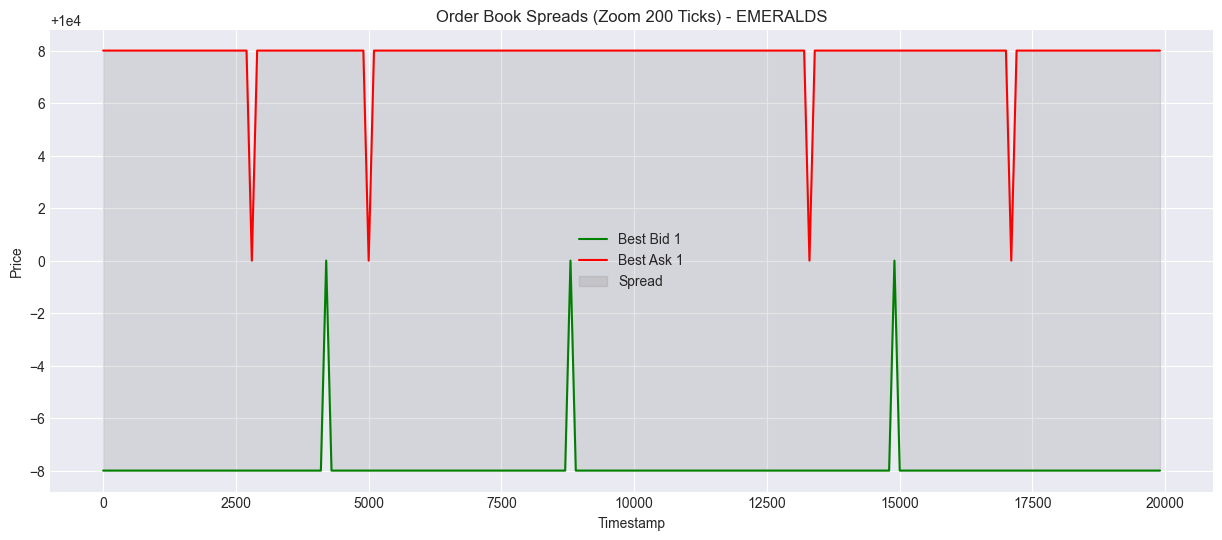

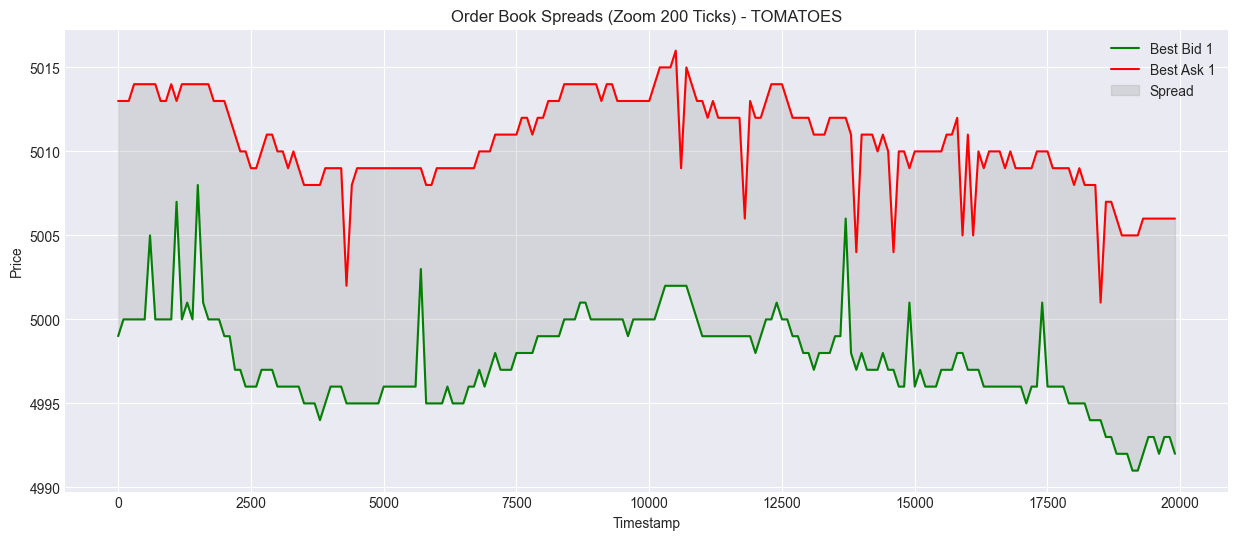

In [18]:
def plot_order_book_zoomed(df, product_name, ticks=200):
    # Cắt 200 dòng đầu để dễ quan sát (micro-structure)
    df_zoom = df.head(ticks)
    plt.figure(figsize=(15, 6))
    
    # Plot Best Bid
    plt.plot(df_zoom['timestamp'], df_zoom['bid_price_1'], label='Best Bid 1', color='green', linewidth=1.5)
    
    # Plot Best Ask
    plt.plot(df_zoom['timestamp'], df_zoom['ask_price_1'], label='Best Ask 1', color='red', linewidth=1.5)
    
    # Fill vùng Spread ở giữa
    plt.fill_between(df_zoom['timestamp'], df_zoom['bid_price_1'], df_zoom['ask_price_1'], color='gray', alpha=0.2, label='Spread')
    
    plt.title(f'Order Book Spreads (Zoom 200 Ticks) - {product_name}')
    plt.xlabel('Timestamp')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

plot_order_book_zoomed(df_emeralds, 'EMERALDS')
plot_order_book_zoomed(df_tomatoes, 'TOMATOES')


## 4B. Biểu Đồ Chiều Sâu Sổ Lệnh (Depth Chart Snapshot)
Order Book của một Product tại một Thời điểm cụ thể (VD: tick 0). Cho ta thấy 3 mức độ (Levels) của Bid và Ask cùng một lúc. Mức mà người mua/bán tập trung tạo ra "Bức tường giá - Price Wall".

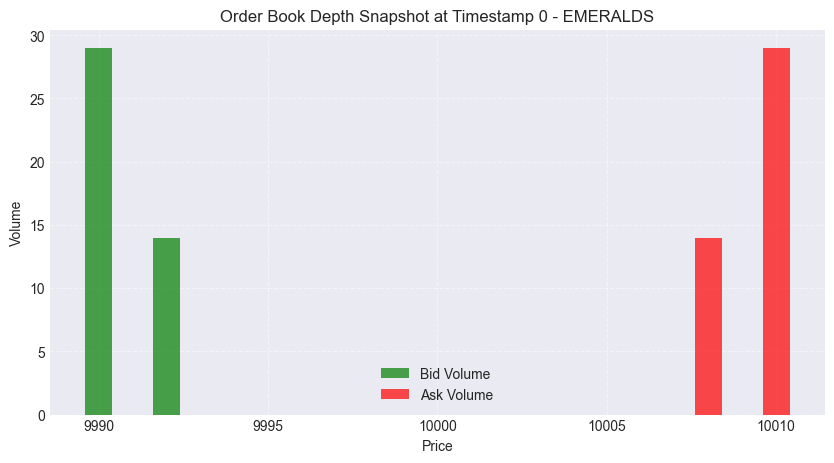

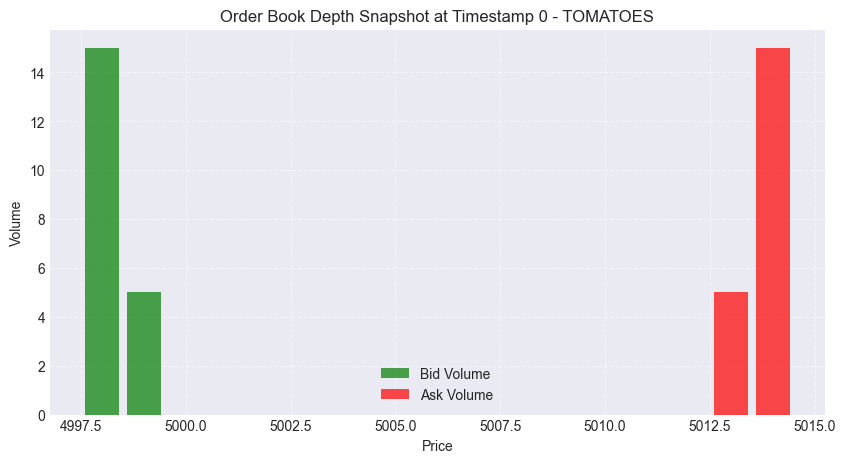

In [19]:
def plot_depth_snapshot(df, product_name, time_stamp=0):
    snapshot = df[df['timestamp'] == time_stamp]
    if snapshot.empty: return
    
    row = snapshot.iloc[0]
    
    # 3 Level của Bids (Xanh) và Asks (Đỏ) 
    bids, asks = [], []
    for i in range(1, 4):
        if pd.notna(row.get(f'bid_price_{i}')): bids.append((row[f'bid_price_{i}'], row[f'bid_volume_{i}']))
        if pd.notna(row.get(f'ask_price_{i}')): asks.append((row[f'ask_price_{i}'], abs(row[f'ask_volume_{i}'])))
            
    bids = sorted(bids, key=lambda x: x[0])
    asks = sorted(asks, key=lambda x: x[0])
    
    plt.figure(figsize=(10, 5))
    if bids:
        plt.bar([b[0] for b in bids], [b[1] for b in bids], width=0.8, color='green', alpha=0.7, label='Bid Volume')
    if asks:
        plt.bar([a[0] for a in asks], [a[1] for a in asks], width=0.8, color='red', alpha=0.7, label='Ask Volume')
        
    plt.title(f'Order Book Depth Snapshot at Timestamp {time_stamp} - {product_name}')
    plt.xlabel('Price')
    plt.ylabel('Volume')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Lấy thử sổ lệnh của ngày đầu tiên, timestamp 0 
plot_depth_snapshot(df_emeralds, 'EMERALDS', time_stamp=0)
plot_depth_snapshot(df_tomatoes, 'TOMATOES', time_stamp=0)


## 5. Lệnh Giao Dịch Đáng Ngờ (Khối Lượng Lớn / Bất Thường)
Tìm kiếm các trade có số lượng (quantity) vượt trội hoặc diễn ra ngoài khoảng giá bình thường.

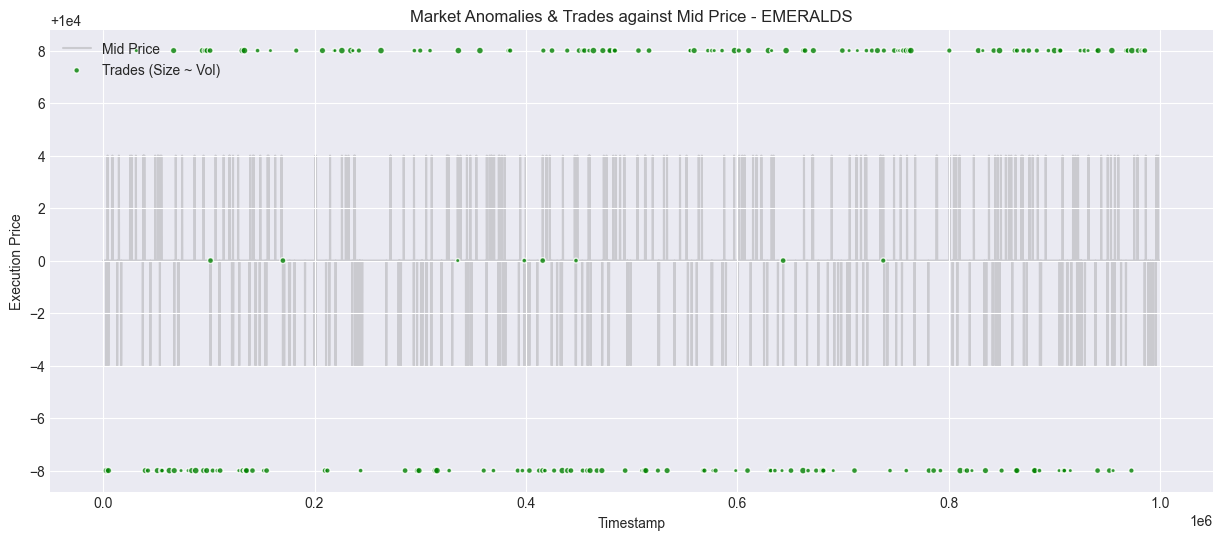

Top 10 khối lượng trade đột biến xả kho/khớp mạnh của EMERALDS:


,timestamp,buyer,seller,symbol,currency,price,quantity
0,3200,NaN,NaN,EMERALDS,XIRECS,9992.0,8
28,62700,NaN,NaN,EMERALDS,XIRECS,9992.0,8
50,87600,NaN,NaN,EMERALDS,XIRECS,9992.0,8
190,314400,NaN,NaN,EMERALDS,XIRECS,9992.0,8
140,225900,NaN,NaN,EMERALDS,XIRECS,10008.0,8
146,234400,NaN,NaN,EMERALDS,XIRECS,10008.0,8
210,336100,NaN,NaN,EMERALDS,XIRECS,10008.0,8
276,434400,NaN,NaN,EMERALDS,XIRECS,9992.0,8
159,262900,NaN,NaN,EMERALDS,XIRECS,10008.0,8
216,356500,NaN,NaN,EMERALDS,XIRECS,10008.0,8


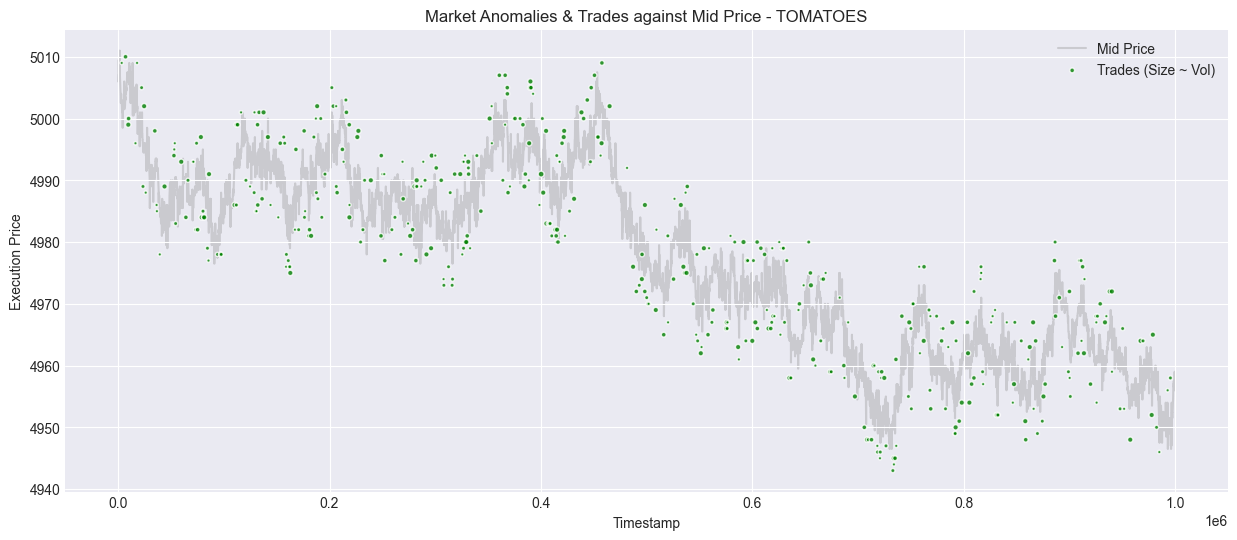

Top 10 khối lượng trade đột biến xả kho/khớp mạnh của TOMATOES:


,timestamp,buyer,seller,symbol,currency,price,quantity
245,400200,NaN,NaN,TOMATOES,XIRECS,4991.0,6
621,977900,NaN,NaN,TOMATOES,XIRECS,4952.0,5
622,979000,NaN,NaN,TOMATOES,XIRECS,4965.0,5
45,81400,NaN,NaN,TOMATOES,XIRECS,4984.0,5
40,79100,NaN,NaN,TOMATOES,XIRECS,4984.0,5
39,78300,NaN,NaN,TOMATOES,XIRECS,4997.0,5
27,59700,NaN,NaN,TOMATOES,XIRECS,4993.0,5
560,875500,NaN,NaN,TOMATOES,XIRECS,4955.0,5
554,865700,NaN,NaN,TOMATOES,XIRECS,4967.0,5
549,862500,NaN,NaN,TOMATOES,XIRECS,4963.0,5


In [20]:
def analyze_trades_with_price(trades_df, prices_df, product_name):
    target_trades = trades_df[trades_df['symbol'] == product_name].copy()
    if target_trades.empty:
        print(f"Không có giao dịch nào cho {product_name}.")
        return

    # Visualizing trades đè lên đường Mid Price 
    # (Để thấy giá khớp mua/bán nằm ngoài hay trong spread giá trị thực)
    plt.figure(figsize=(15, 6))
    
    # 1. Đường Midprice (Khá rối nếu vẽ cả, nhưng nên làm background mờ)
    price_base = prices_df[prices_df['product'] == product_name]
    plt.plot(price_base['timestamp'], price_base['mid_price'], label='Mid Price', color='grey', alpha=0.3, zorder=0)

    # 2. Bubble Scatter Lệnh Giao Dịch
    sc = plt.scatter(target_trades['timestamp'], target_trades['price'], 
                s=target_trades['quantity'].abs() * 3, # Kích thước bong bóng càng to khối lượng càng khủng
                c=target_trades['quantity'].apply(lambda x: 'red' if x < 0 else 'green'), # Đỏ là bán, Xanh là mua
                edgecolors='w', alpha=0.8, label='Trades (Size ~ Vol)')

    plt.title(f'Market Anomalies & Trades against Mid Price - {product_name}')
    plt.xlabel('Timestamp')
    plt.ylabel('Execution Price')
    plt.legend(loc='best')
    plt.show()

    # Tìm các lệnh có khối lượng lớn đâm xuyên thị trường
    print(f"Top 10 khối lượng trade đột biến xả kho/khớp mạnh của {product_name}:")
    display(target_trades.assign(abs_quantity=target_trades['quantity'].abs()).sort_values(by='abs_quantity', ascending=False).head(10).drop(columns=['abs_quantity']))

analyze_trades_with_price(df_trades, df_prices, 'EMERALDS')
analyze_trades_with_price(df_trades, df_prices, 'TOMATOES')


## 6. Đánh giá Thuật toán của Bot (Log File)
Chúng ta sẽ load file `21029.log` của bot chạy từ Backtester để:
1. Xem PnL (Lợi nhuận - Lỗ) của bot di chuyển thế nào.
2. Đưa các lệnh Khớp Mua / Bán của bot đè lên Spread (Order Book) để xem bot của chúng ta "Ngu/Khôn" ở điểm nào.
3. Xem biến động Vị thế (Position) - liệu bot có bị kẹt hàng ở mức tối đa $\pm 80$ hay không.

In [21]:
import json
from io import StringIO

log_file_path = "i:/Prosperity/data/53409/53409.log"
with open(log_file_path, 'r') as f:
    log_data = json.load(f)

# 1. Đọc PnL tu activitiesLog (CSV-like)
activities_csv = log_data.get('activitiesLog', '')
df_bot_activities = pd.read_csv(StringIO(activities_csv), sep=';')
df_bot_emeralds_activity = df_bot_activities[df_bot_activities['product'] == 'EMERALDS'].copy()
df_bot_tomatoes_activity = df_bot_activities[df_bot_activities['product'] == 'TOMATOES'].copy()

# 2. Doc cac Trade ma SUBMISSION (tuc bot cua minh) da tham gia
trade_history = log_data.get('tradeHistory', [])
df_bot_trades = pd.DataFrame(trade_history)

if not df_bot_trades.empty:
    df_bot_trades['is_buy'] = df_bot_trades['buyer'] == 'SUBMISSION'
    df_bot_trades['is_sell'] = df_bot_trades['seller'] == 'SUBMISSION'
    
    # Loc Emeralds
    df_our_emeralds_trades = df_bot_trades[df_bot_trades['symbol'] == 'EMERALDS'].copy()
    
display(df_our_emeralds_trades.head())


,timestamp,buyer,seller,symbol,currency,price,quantity,is_buy,is_sell
2,5900,,SUBMISSION,EMERALDS,XIRECS,10007.0,8,False,True
3,9700,SUBMISSION,,EMERALDS,XIRECS,9993.0,6,True,False
10,23700,SUBMISSION,,EMERALDS,XIRECS,9993.0,4,True,False
13,28700,SUBMISSION,,EMERALDS,XIRECS,9993.0,3,True,False
14,29800,SUBMISSION,,EMERALDS,XIRECS,9993.0,8,True,False


C:\Users\LOQ\AppData\Local\Temp\ipykernel_27440\3601864154.py:29: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_activity_merged['cumulative_position'] = df_activity_merged['cumulative_position'].fillna(method='ffill').fillna(0)


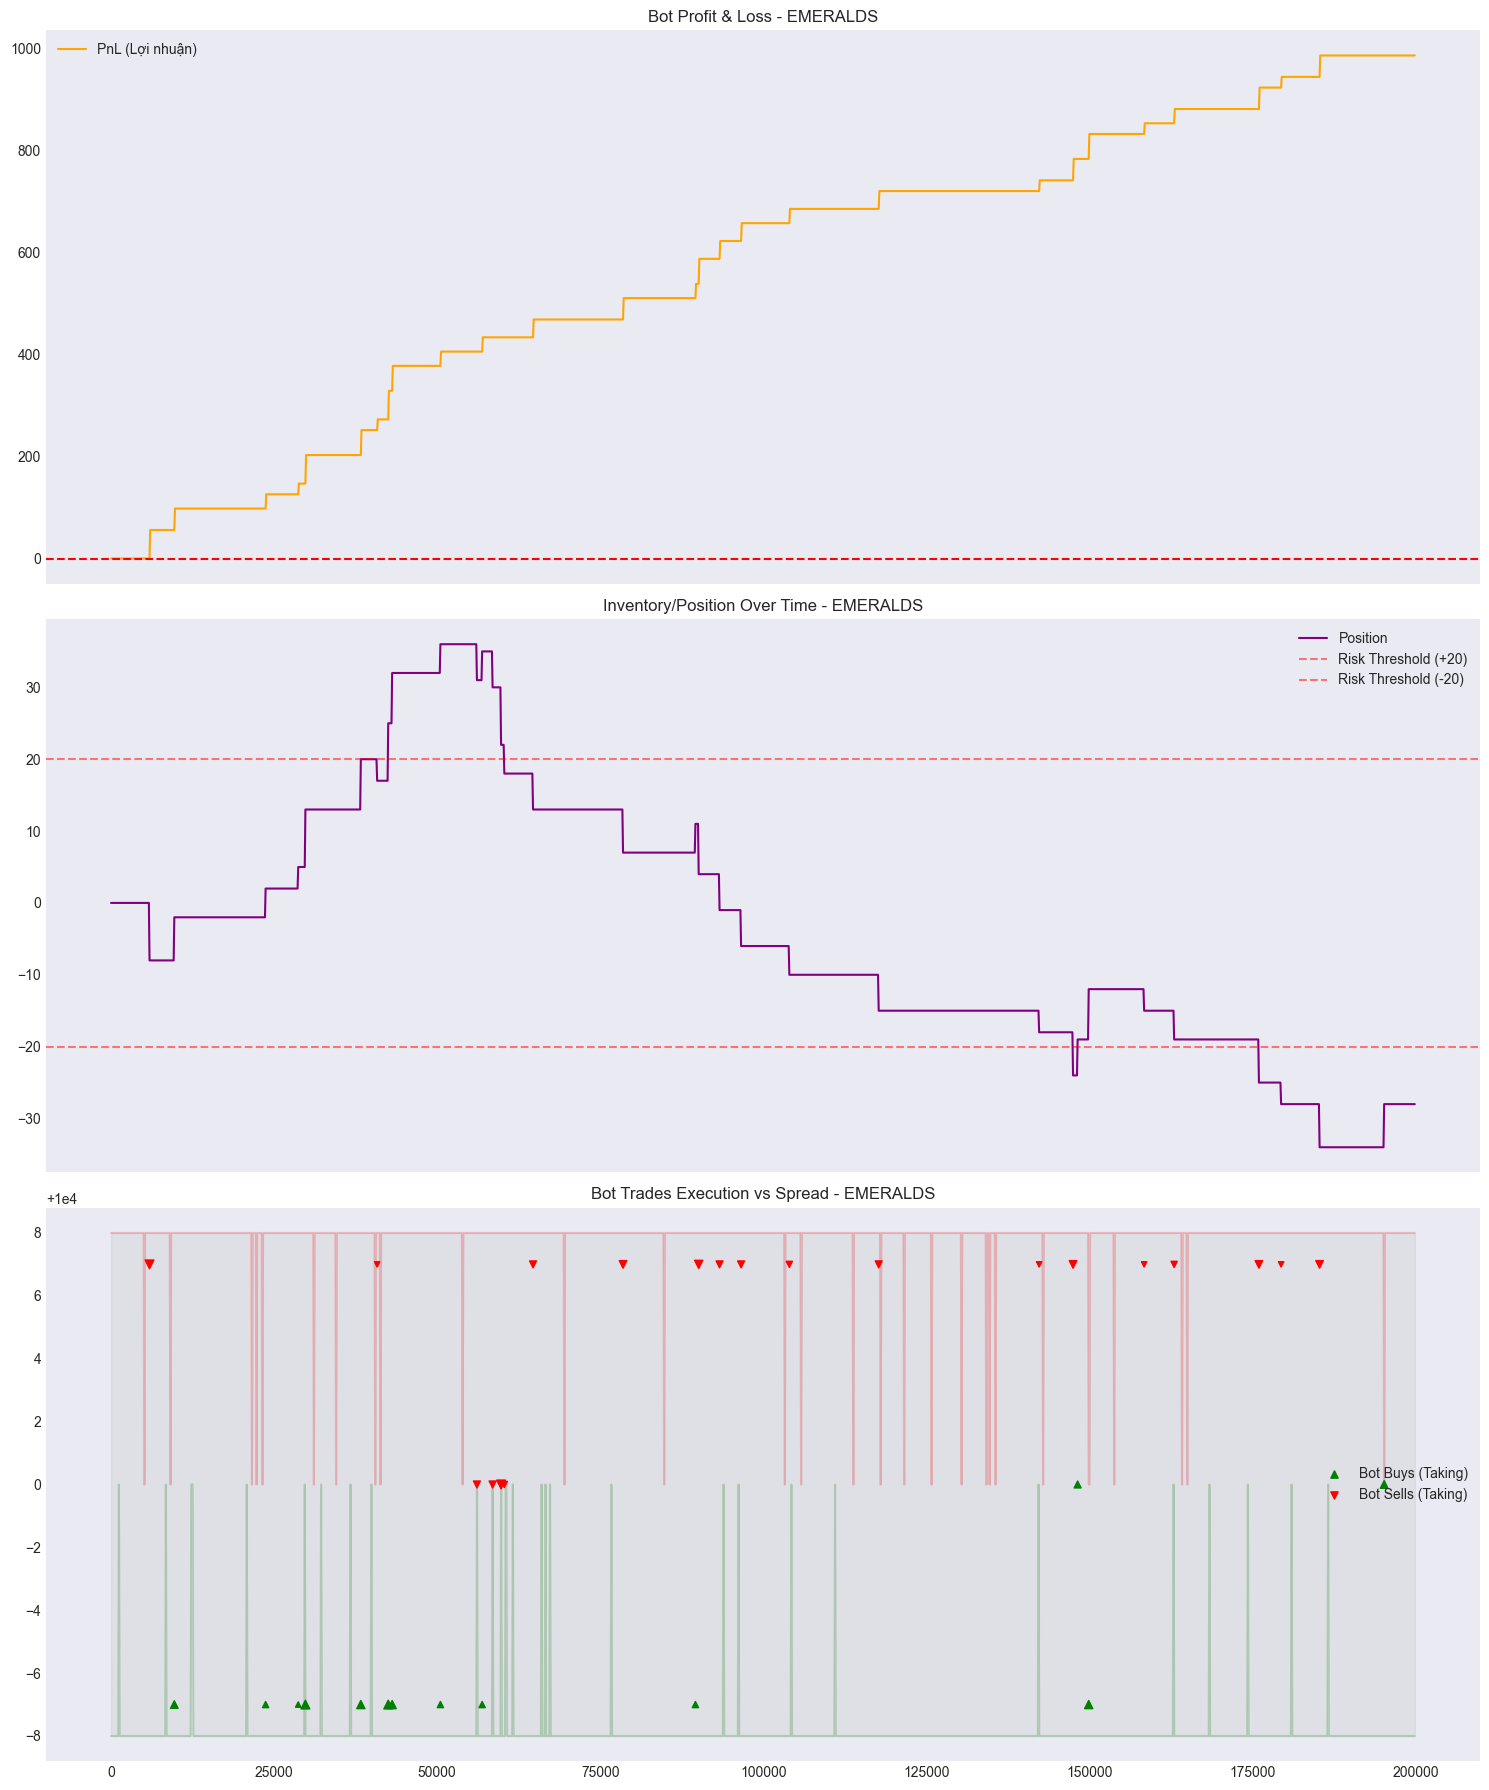

In [22]:
def plot_bot_performance(df_activity, df_trades, product_name):
    # Tinh luỹ kế Vị thế (Position)
    df_product_trades = df_trades[df_trades['symbol'] == product_name].copy()
    
    if df_product_trades.empty:
        print(f"Bot không Trade {product_name}")
        return
        
    df_product_trades['pos_change'] = df_product_trades.apply(
        lambda row: row['quantity'] if row['is_buy'] else -row['quantity'], axis=1
    )
    # Gom nhóm theo timestamp vì có nhiều trade khớp trong cùng 1 tick
    pos_by_time = df_product_trades.groupby('timestamp')['pos_change'].sum().reset_index()
    pos_by_time['cumulative_position'] = pos_by_time['pos_change'].cumsum()
    
    # Vẽ Biểu Đồ
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 18), sharex=True)

    # 1. PnL Over Time
    ax1.plot(df_activity['timestamp'], df_activity['profit_and_loss'], label='PnL (Lợi nhuận)', color='orange')
    ax1.set_title(f'Bot Profit & Loss - {product_name}')
    ax1.axhline(0, color='r', linestyle='--')
    ax1.legend()
    ax1.grid()

    # 2. Vị Thế (Hold mập hàng không?)
    # Map position về thời gian của Activity
    df_activity_merged = pd.merge(df_activity, pos_by_time[['timestamp', 'cumulative_position']], on='timestamp', how='left')
    df_activity_merged['cumulative_position'] = df_activity_merged['cumulative_position'].fillna(method='ffill').fillna(0)
    
    ax2.plot(df_activity_merged['timestamp'], df_activity_merged['cumulative_position'], label='Position', color='purple')
    ax2.axhline(20, color='r', linestyle='--', alpha=0.5, label='Risk Threshold (+20)')
    ax2.axhline(-20, color='r', linestyle='--', alpha=0.5, label='Risk Threshold (-20)')
    ax2.set_title(f'Inventory/Position Over Time - {product_name}')
    ax2.legend()
    ax2.grid()

    # 3. Market Trades đè lên Order Book
    ax3.plot(df_activity['timestamp'], df_activity['bid_price_1'], color='green', alpha=0.2)
    ax3.plot(df_activity['timestamp'], df_activity['ask_price_1'], color='red', alpha=0.2)
    ax3.fill_between(df_activity['timestamp'], df_activity['bid_price_1'], df_activity['ask_price_1'], color='gray', alpha=0.1)

    buys = df_product_trades[df_product_trades['is_buy']]
    sells = df_product_trades[df_product_trades['is_sell']]
    
    ax3.scatter(buys['timestamp'], buys['price'], color='green', marker='^', s=buys['quantity']*5, label='Bot Buys (Taking)', zorder=5)
    ax3.scatter(sells['timestamp'], sells['price'], color='red', marker='v', s=sells['quantity']*5, label='Bot Sells (Taking)', zorder=5)
    ax3.set_title(f'Bot Trades Execution vs Spread - {product_name}')
    ax3.legend()
    ax3.grid()
    
    plt.tight_layout()
    plt.show()

plot_bot_performance(df_bot_emeralds_activity, df_bot_trades, 'EMERALDS')


## 7. Phân tích Các Lỗi Sai (Mistakes) Ở Thuật Toán Gốc
Ở phần này, chúng ta trích xuất dữ liệu của log `53409.log` để chỉ đích danh 3 lỗi chí mạng như đã phân tích:
1. Lỗi hàm `min()/max()` lấy sai giá trị tốt nhất dẫn đến Spread bị ước lượng sai.
2. `wall_mid` bị thả trượt tự do (không bị neo ở 10000) khiến bot hiểu sai Fair Value.
3. Base case báo giá Mua/Bán sai khiến lệnh chờ (Making) đánh mất thanh khoản tốt 9999/10001.

----- PHÂN TÍCH LỖI TRONG 53409.LOG -----

1. LỖI FAIR VALUE: wall_mid lẽ ra không bao giờ đổi (10000).
=> Nhưng bot đã tự tính và làm giá trị trượt từ 9996.0 đến 10004.0

2. LỖI BỎ LỠ LỢI NHUẬN TỐI ƯU:
Giá mua CAO NHẤT bot dám khớp: 10000.0 (Đúng ra phải dám mua 9999)
Giá bán THẤP NHẤT bot chịu bán: 10000.0 (Đúng ra phải chịu bán 10001)

=> Hậu quả: Bot Mua/Bán ở tít giá 9993-10007, tự thu hẹp cửa làm ăn (chỉ khớp 29 lệnh so với >2000 ticks cơ hội).


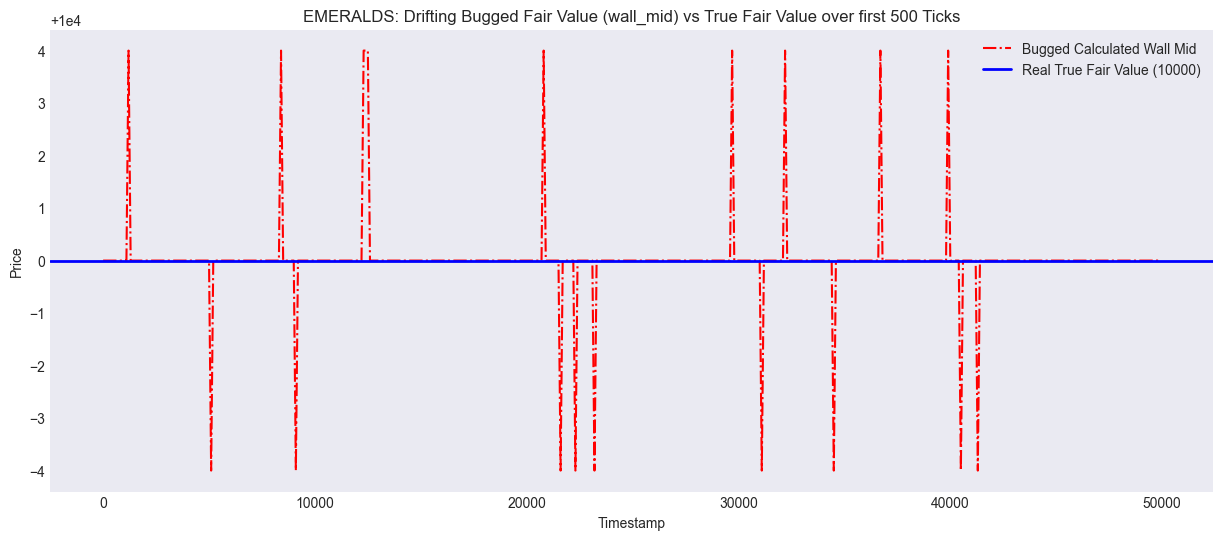

In [23]:
def analyze_old_bugs(df_activity, df_trades):
    print("----- PHÂN TÍCH LỖI TRONG 53409.LOG -----\n")
    
    ema_acts = df_activity[df_activity['product'] == 'EMERALDS'].copy()
    ema_trades = df_trades[df_trades['symbol'] == 'EMERALDS'].copy()
    
    # 1. Lỗi Drift wall_mid (Fair Value nội tại)
    # Lẽ ra EMA luôn là 10000. Hàm cũ tính (bid_wall + ask_wall) / 2
    # Do lấy max_ask, min_bid sai -> wall_mid bị tính sai từ gốc
    
    ema_acts['bug_wall_mid'] = (ema_acts['bid_price_1'] + ema_acts['ask_price_1']) / 2
    
    print(f"1. LỖI FAIR VALUE: wall_mid lẽ ra không bao giờ đổi (10000).")
    print(f"=> Nhưng bot đã tự tính và làm giá trị trượt từ {ema_acts['bug_wall_mid'].min()} đến {ema_acts['bug_wall_mid'].max()}\n")
    
    # 2. Lỗi Không chịu Báo giá 9999 / 10001 (Do base_case sai)
    our_buys = ema_trades[ema_trades['is_buy']]
    our_sells = ema_trades[ema_trades['is_sell']]
    
    print(f"2. LỖI BỎ LỠ LỢI NHUẬN TỐI ƯU:")
    print(f"Giá mua CAO NHẤT bot dám khớp: {our_buys['price'].max()} (Đúng ra phải dám mua 9999)")
    print(f"Giá bán THẤP NHẤT bot chịu bán: {our_sells['price'].min()} (Đúng ra phải chịu bán 10001)\n")
    
    print("=> Hậu quả: Bot Mua/Bán ở tít giá 9993-10007, tự thu hẹp cửa làm ăn (chỉ khớp 29 lệnh so với >2000 ticks cơ hội).")

    # Trực quan biểu đồ
    plt.figure(figsize=(15, 6))
    
    plt.plot(ema_acts['timestamp'].head(500), ema_acts['bug_wall_mid'].head(500), label='Bugged Calculated Wall Mid', color='red', linestyle='-.')
    plt.axhline(10000, color='blue', label='Real True Fair Value (10000)', linestyle='-', linewidth=2)
    
    plt.title('EMERALDS: Drifting Bugged Fair Value (wall_mid) vs True Fair Value over first 500 Ticks')
    plt.xlabel('Timestamp')
    plt.ylabel('Price')
    plt.legend()
    plt.grid()
    plt.show()

analyze_old_bugs(df_bot_activities, df_bot_trades)